<a href="https://colab.research.google.com/github/RajaShahzaibNaseer/DeepLearningPractice/blob/main/house_price_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None

Descriptive Statistics:
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  54

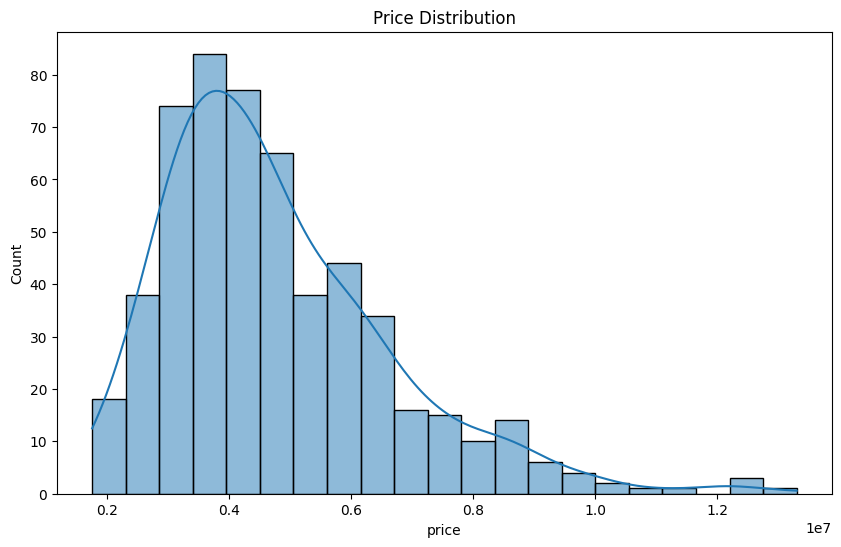


Model Performance:
Mean Absolute Error: ₹248,375.74
R-squared Score: 0.9559


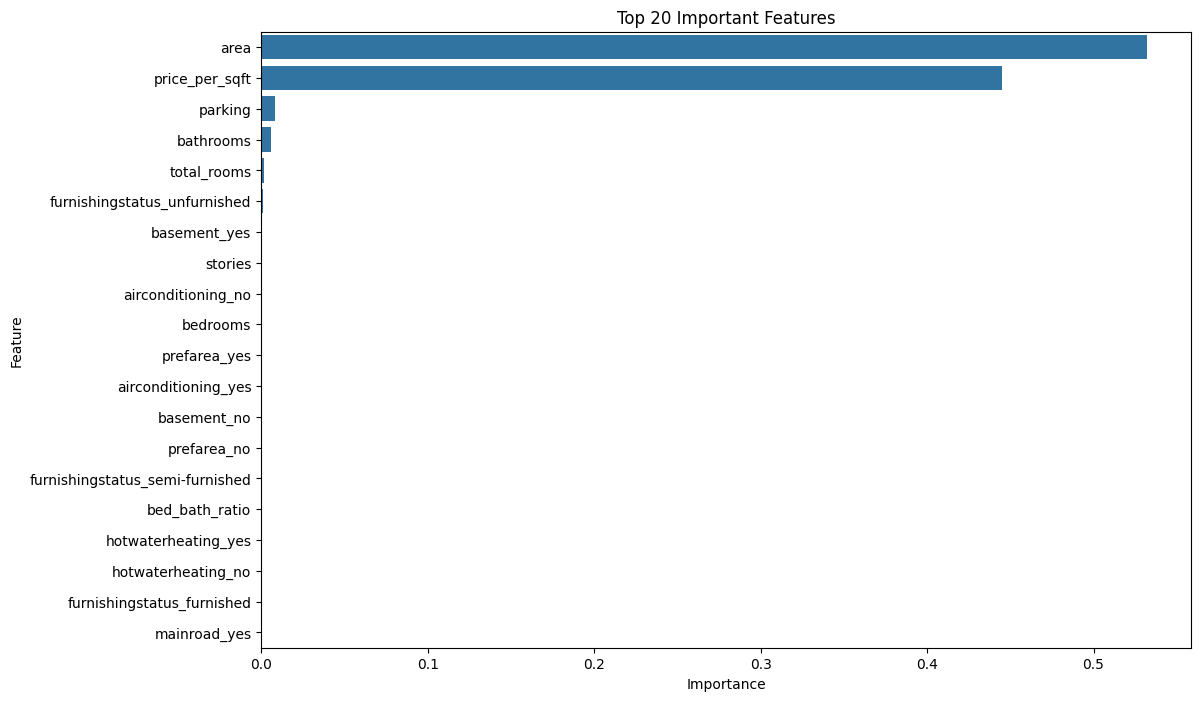


Predicted Price for Sample House: ₹8,849,720.36


In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/dataset/Housing.csv')

# Data Exploration
print("Dataset Info:")
print(df.info())
print("\nDescriptive Statistics:")
print(df.describe())

# Visualize price distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True)
plt.title('Price Distribution')
plt.show()

# Feature Engineering
df['price_per_sqft'] = df['price'] / df['area']
df['total_rooms'] = df['bedrooms'] + df['bathrooms']
df['bed_bath_ratio'] = df['bedrooms'] / (df['bathrooms'] + 0.001)  # Avoid division by zero

# Separate features and target
X = df.drop('price', axis=1)
y = df['price']

# Identify categorical and numerical columns
categorical_cols = ['mainroad', 'guestroom', 'basement',
                   'hotwaterheating', 'airconditioning', 'prefarea',
                   'furnishingstatus']
numerical_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking',
                 'price_per_sqft', 'total_rooms', 'bed_bath_ratio']

# Preprocessing pipeline
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Model pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ))
])

# Train the model
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print(f"Mean Absolute Error: ₹{mae:,.2f}")
print(f"R-squared Score: {r2:.4f}")

# Feature Importance
feature_encoder = model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_features = feature_encoder.get_feature_names_out(categorical_cols)
all_features = numerical_cols + list(cat_features)

try:
    importances = model.named_steps['regressor'].feature_importances_
    feat_imp = pd.DataFrame({'Feature': all_features, 'Importance': importances})
    feat_imp = feat_imp.sort_values('Importance', ascending=False).head(20)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feat_imp)
    plt.title('Top 20 Important Features')
    plt.show()
except AttributeError:
    print("Feature importance not available for this model type")

# Example prediction
sample_house = pd.DataFrame({
    'area': [3500],
    'bedrooms': [3],
    'bathrooms': [2],
    'stories': [2],
    'mainroad': ['yes'],
    'guestroom': ['no'],
    'basement': ['yes'],
    'hotwaterheating': ['no'],
    'airconditioning': ['yes'],
    'parking': [1],
    'prefarea': ['yes'],
    'furnishingstatus': ['furnished'],
    'price_per_sqft': [0],  # Will be recalculated
    'total_rooms': [0],     # Will be recalculated
    'bed_bath_ratio': [0]   # Will be recalculated
})

# Recalculate derived features
sample_house['price_per_sqft'] = sample_house['area'] * 3000  # Example calculation
sample_house['total_rooms'] = sample_house['bedrooms'] + sample_house['bathrooms']
sample_house['bed_bath_ratio'] = sample_house['bedrooms'] / sample_house['bathrooms']

predicted_price = model.predict(sample_house)
print(f"\nPredicted Price for Sample House: ₹{predicted_price[0]:,.2f}")